# Análisis Univariado del Dataset Bitcoin

In [1]:
# Se importan librerias necesarias para el análisis de datos y visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Nuevas librerías para la conexión a la base de datos y variables de entorno
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, exc

In [2]:
# se cargan los datos de bitcoin desde un archivo CSV
# df = pd.read_csv("../data/clean/criptoradar_crypto_final_clean.csv")

In [3]:
try:
    # 1. Cargar las variables de entorno
    load_dotenv(dotenv_path="../.env") 
    
    db_user = os.getenv("DB_USER")
    db_pass = os.getenv("DB_PASS")
    db_host = os.getenv("DB_HOST")
    db_name = os.getenv("DB_NAME")
    
    # Validar que no falte ninguna variable crítica en el .env
    if not all([db_user, db_pass, db_host, db_name]):
        raise ValueError("Faltan una o más variables de entorno en el archivo .env")

    # 2. Crear la cadena de conexión y el motor (engine)
    connection_string = f"mysql+pymysql://{db_user}:{db_pass}@{db_host}/{db_name}"
    engine = create_engine(connection_string)
    
    # 3. Definir la consulta para Bitcoin
    query = """
    SELECT crypto_id, open, high, low, close, volume, datetime 
    FROM crypto_precios;
    """
    
    # 4. Intentar cargar los datos en el DataFrame
    df = pd.read_sql(query, con=engine)
    print(f"¡Conexión exitosa! Se han cargado {len(df)} registros de criptomonedas.")

except ValueError as ve:
    print(f"Error de Configuración: {ve}")
except exc.SQLAlchemyError as se:
    print(f"Error de Base de Datos: No se pudo conectar o ejecutar la consulta.\nDetalles: {se}")
except Exception as e:
    print(f"Error Inesperado: {e}")

¡Conexión exitosa! Se han cargado 6400 registros de criptomonedas.


In [4]:
# se observan las primeras filas del DataFrame para entender su estructura y contenido
df.head()

,crypto_id,open,high,low,close,volume,datetime
0,bitcoin,60791.91,61064.93,56571.00,56885.95,6.632771e+08,2024-04-30
1,bitcoin,56885.95,59467.95,56636.36,59263.71,6.159544e+08,2024-05-01
2,bitcoin,59263.71,62117.65,58628.50,61679.40,5.698631e+08,2024-05-02
3,bitcoin,61679.40,64542.02,61538.49,63605.83,5.168242e+08,2024-05-03
4,bitcoin,63605.83,64632.11,62890.63,64433.80,5.043761e+08,2024-05-04


In [5]:
# información general del DataFrame, incluyendo el número de entradas, columnas, tipos de datos y memoria utilizada
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   crypto_id  6400 non-null   str    
 1   open       6400 non-null   float64
 2   high       6400 non-null   float64
 3   low        6400 non-null   float64
 4   close      6400 non-null   float64
 5   volume     6400 non-null   float64
 6   datetime   6400 non-null   str    
dtypes: float64(5), str(2)
memory usage: 454.8 KB


In [6]:
# Dimensiones del DataFrame, es decir, el número de filas y columnas
df.shape

(6400, 7)

In [7]:
# Valores nulos por columna, para identificar si hay datos faltantes que puedan afectar el análisis
df.isnull().sum()

crypto_id    0
open         0
high         0
low          0
close        0
volume       0
datetime     0
dtype: int64

Interpretación:

No se encontraron valores nulos, por lo que el conjunto de datos presenta una buena calidad para realizar el análisis.

In [8]:
# Estadisticas descriptivas del DataFrame
df.describe().T

,count,mean,std,min,25%,50%,75%,max
open,6400.0,2.208598e+04,3.776979e+04,4.241600e-01,4.743822e+01,8.777900e+02,1.701919e+04,1.250070e+05
high,6400.0,2.246180e+04,3.837723e+04,4.380500e-01,5.024295e+01,9.142900e+02,1.742569e+04,1.262000e+05
low,6400.0,2.169364e+04,3.713525e+04,3.822000e-01,4.594565e+01,8.191000e+02,1.579762e+04,1.223254e+05
close,6400.0,2.208646e+04,3.777034e+04,4.241600e-01,4.743822e+01,8.777900e+02,1.701919e+04,1.250070e+05
volume,6400.0,2.891325e+08,3.952280e+08,3.652432e+06,6.792191e+07,1.547366e+08,3.364307e+08,8.220814e+09


In [9]:
# Convertir la columna 'datetime' a tipo datetime para facilitar el análisis temporal
df['fecha'] = pd.to_datetime(df['datetime'])

df = df.sort_values(by='fecha')  # Ordenar el DataFrame por fecha para análisis temporal

In [10]:
# Se crean variables adicionales para el análisis, como la media móvil de 30 días del volumen de transacciones

# Retorno
df["retorno_bitcoin"] = df["close"].pct_change()

# Retorno porcentual
df["retorno_bitcoin"] = df["close"].pct_change() * 100

# Variación absoluta del precio
df["variacion_precio"] = df["close"].diff()

# Ordenar por criptomoneda y fecha
df = df.sort_values(["crypto_id", "fecha"])

# Media móvil de 30 días del precio
df["media_movil_30"] = (
    df.groupby("crypto_id")["close"]
      .transform(lambda x: x.rolling(window=30).mean())
)

# Media móvil de 30 días del volumen
df["volumen_mm30"] = (
    df.groupby("crypto_id")["volume"]
      .transform(lambda x: x.rolling(window=30).mean())
)

# Variable: crypto_id

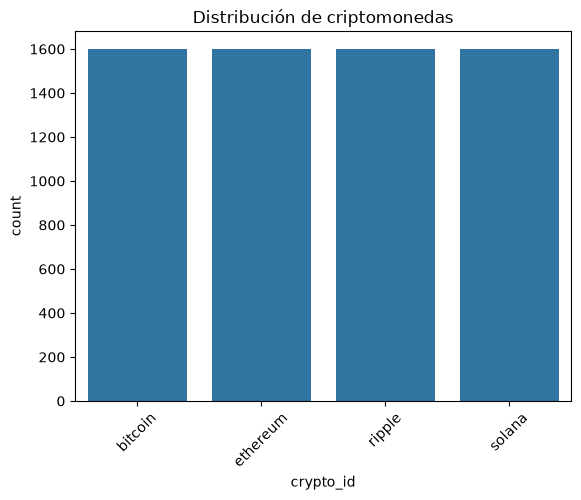

In [11]:
sns.countplot(data=df, x="crypto_id")
plt.title("Distribución de criptomonedas")
plt.xticks(rotation=45)
plt.show()

Text(0.5, 1.0, 'Distribución de criptomonedas')

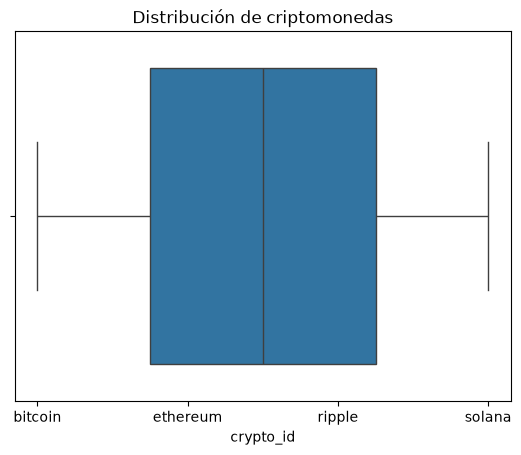

In [12]:
sns.boxplot(x=df["crypto_id"])
plt.title("Distribución de criptomonedas")

Interpretación

Cada criptomoneda posee aproximadamente el mismo número de observaciones, lo que indica que el dataset está balanceado y facilita realizar comparaciones entre activos sin que uno tenga mucho más peso que otro.

In [13]:
# Funcion para crear histogramas por criptomoneda, permitiendo comparar la distribución de una variable específica entre diferentes criptomonedas
def histograma_por_crypto(df, variable, titulo, xlabel, bins=30):

    fig, axes = plt.subplots(2, 2, figsize=(16,10))

    criptos = df["crypto_id"].unique()
    colores = sns.color_palette("Set2", len(criptos))

    for ax, crypto, color in zip(axes.flatten(), criptos, colores):

        datos = df[df["crypto_id"] == crypto]

        sns.histplot(
            data=datos,
            x=variable,
            bins=bins,
            kde=True,
            color=color,
            ax=ax
        )

        ax.set_title(f"{crypto}",
                     fontsize=13,
                     fontweight="bold")

        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frecuencia")

    plt.suptitle(titulo,
                 fontsize=18,
                 fontweight="bold")

    plt.tight_layout()

    plt.show()

# Variable: open

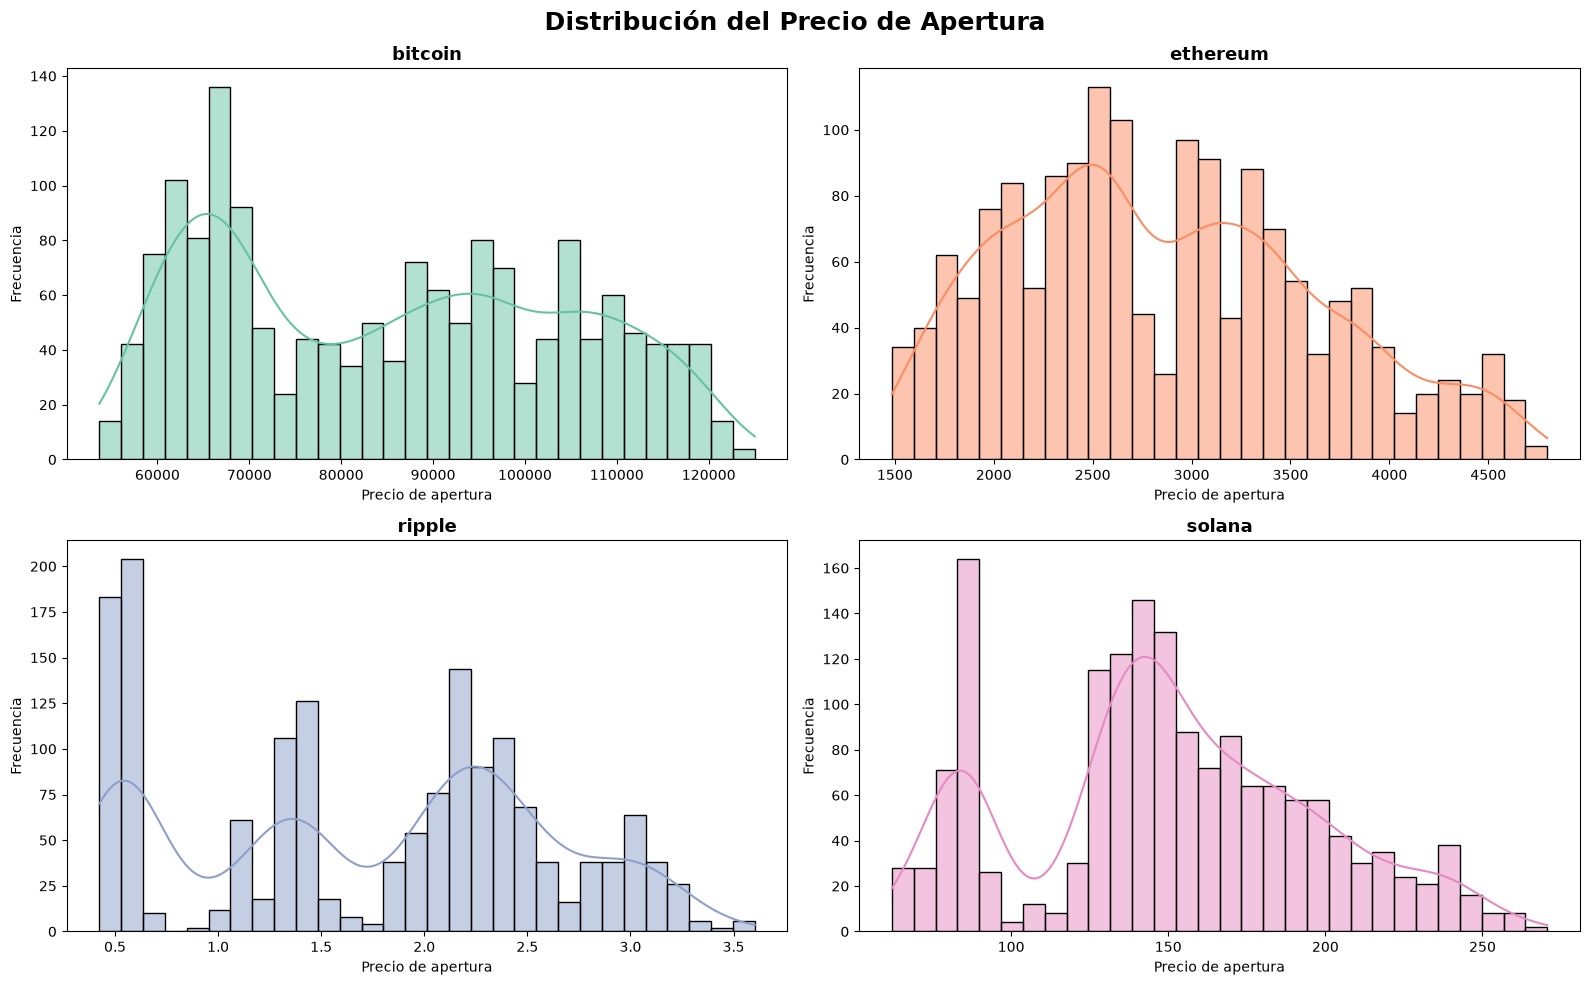

In [14]:
histograma_por_crypto(df,
                      "open",
                      "Distribución del Precio de Apertura",
                      "Precio de apertura")

Interpretación

El precio de apertura presenta una distribución asimétrica hacia la derecha debido a la diferencia de valor entre las criptomonedas analizadas. También es esperable observar valores extremos correspondientes a Bitcoin.

# Variable: High

Corresponde al precio máximo alcanzado durante el día.

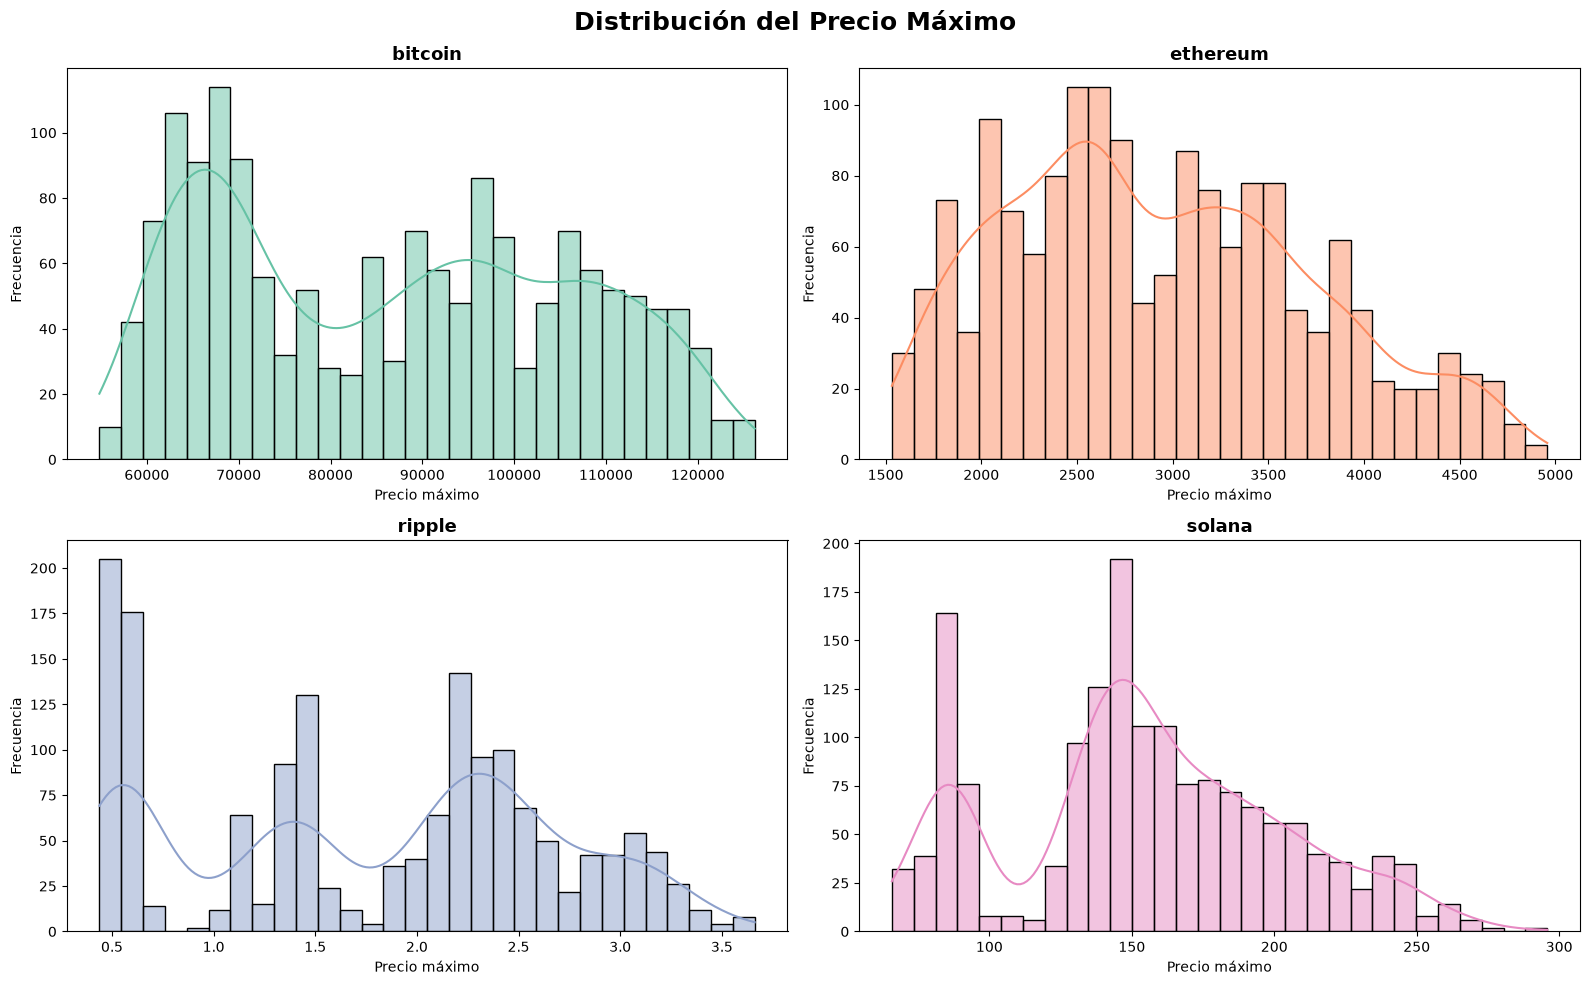

In [15]:
histograma_por_crypto(df,
                      "high",
                      "Distribución del Precio Máximo",
                      "Precio máximo")

Interpretación

La variable mantiene una distribución similar al precio de apertura, con una fuerte dispersión y presencia de valores elevados. Esto refleja jornadas de alta volatilidad en determinados activos

# Variable: Low

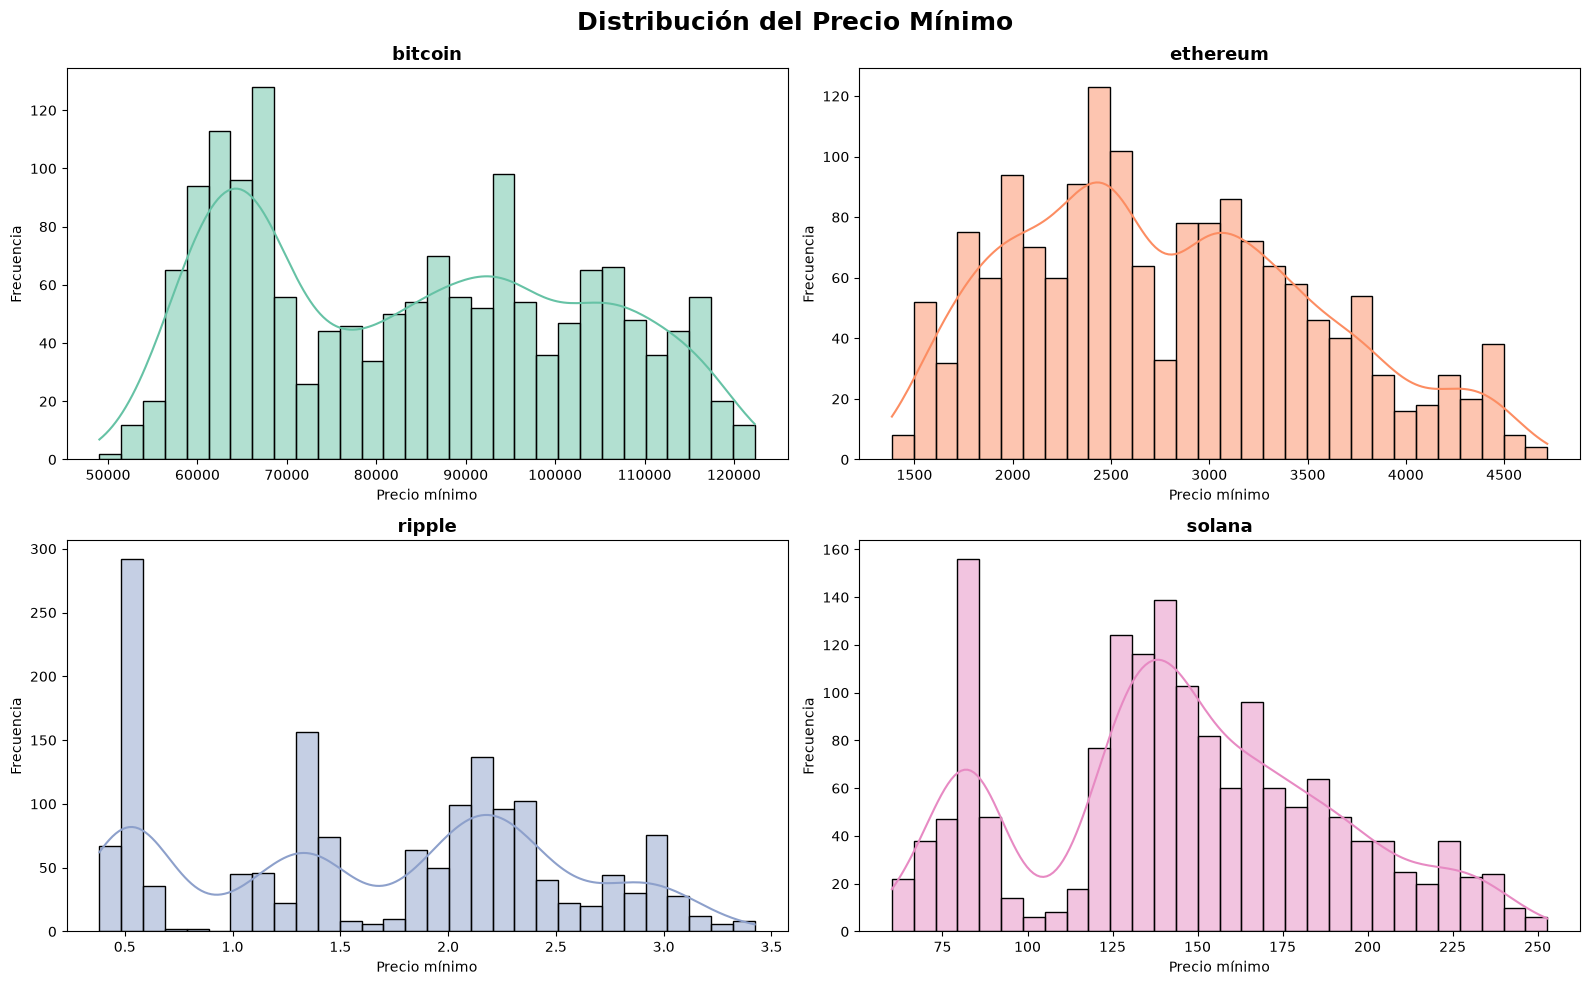

In [16]:
histograma_por_crypto(df,
                      "low",
                      "Distribución del Precio Mínimo",
                      "Precio mínimo")

Interpretación

El precio mínimo también presenta una distribución asimétrica. La diferencia entre el valor mínimo y máximo evidencia la variabilidad diaria del mercado de criptomonedas.

# Variable: Close

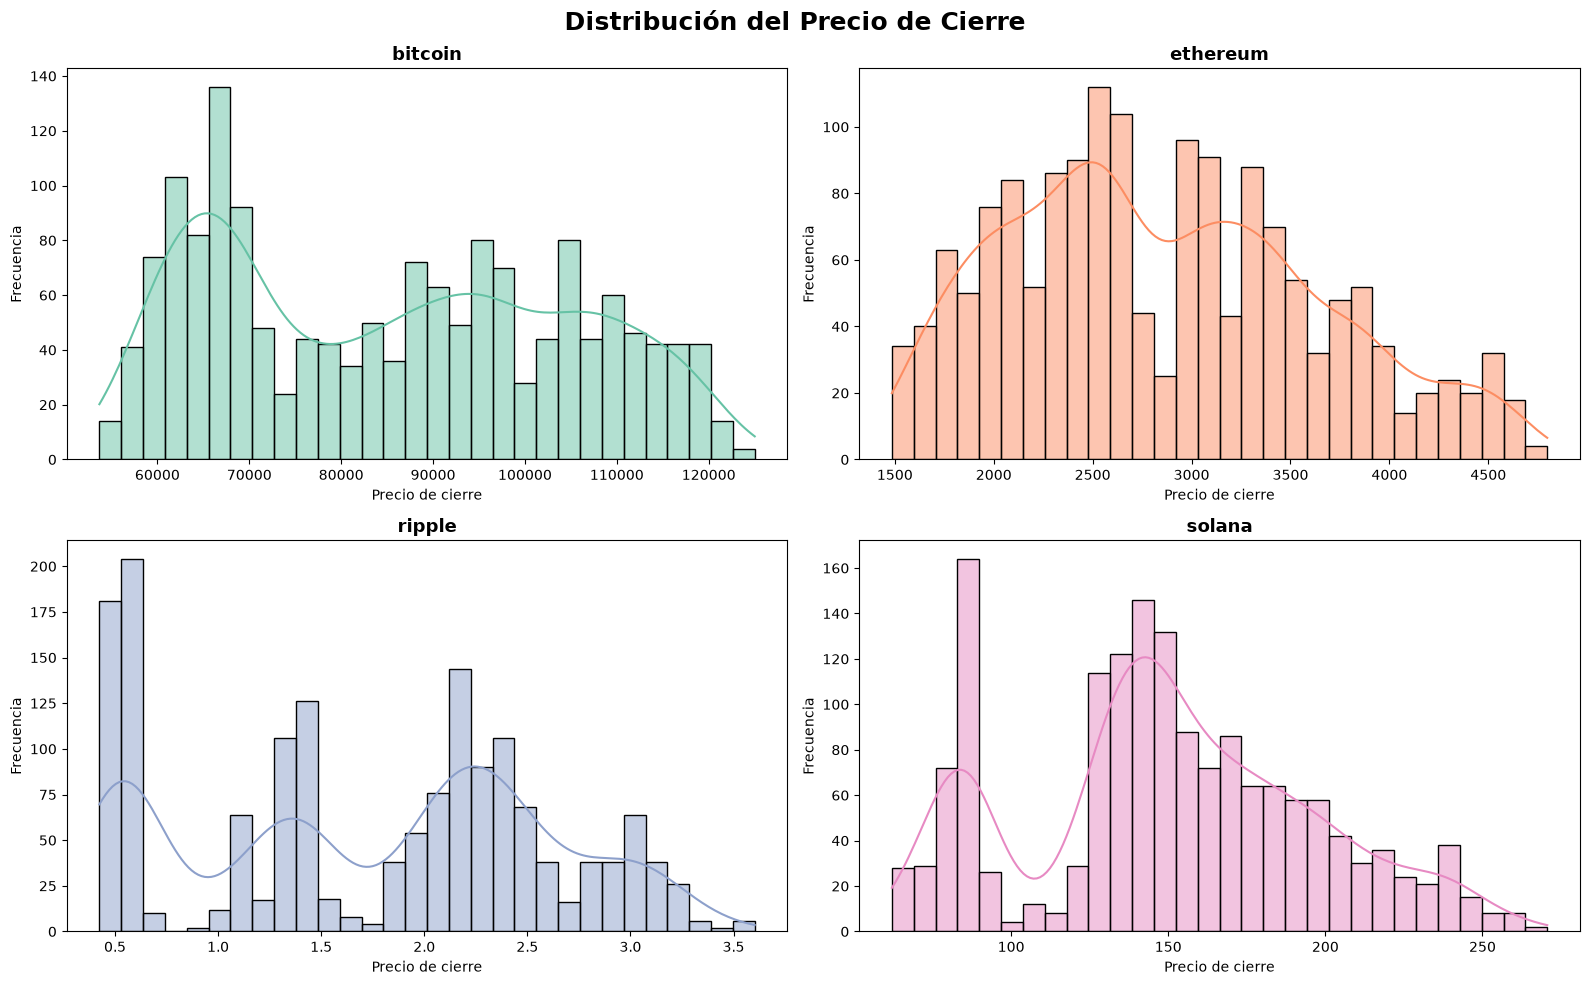

In [17]:
histograma_por_crypto(df,
                      "close",
                      "Distribución del Precio de Cierre",
                      "Precio de cierre")

Interpretación

La distribución del precio de cierre es muy similar a la del precio de apertura, lo que indica que ambos siguen el mismo comportamiento temporal. La existencia de valores extremos responde al amplio rango de precios entre los diferentes activos.

# Variable: Volumen

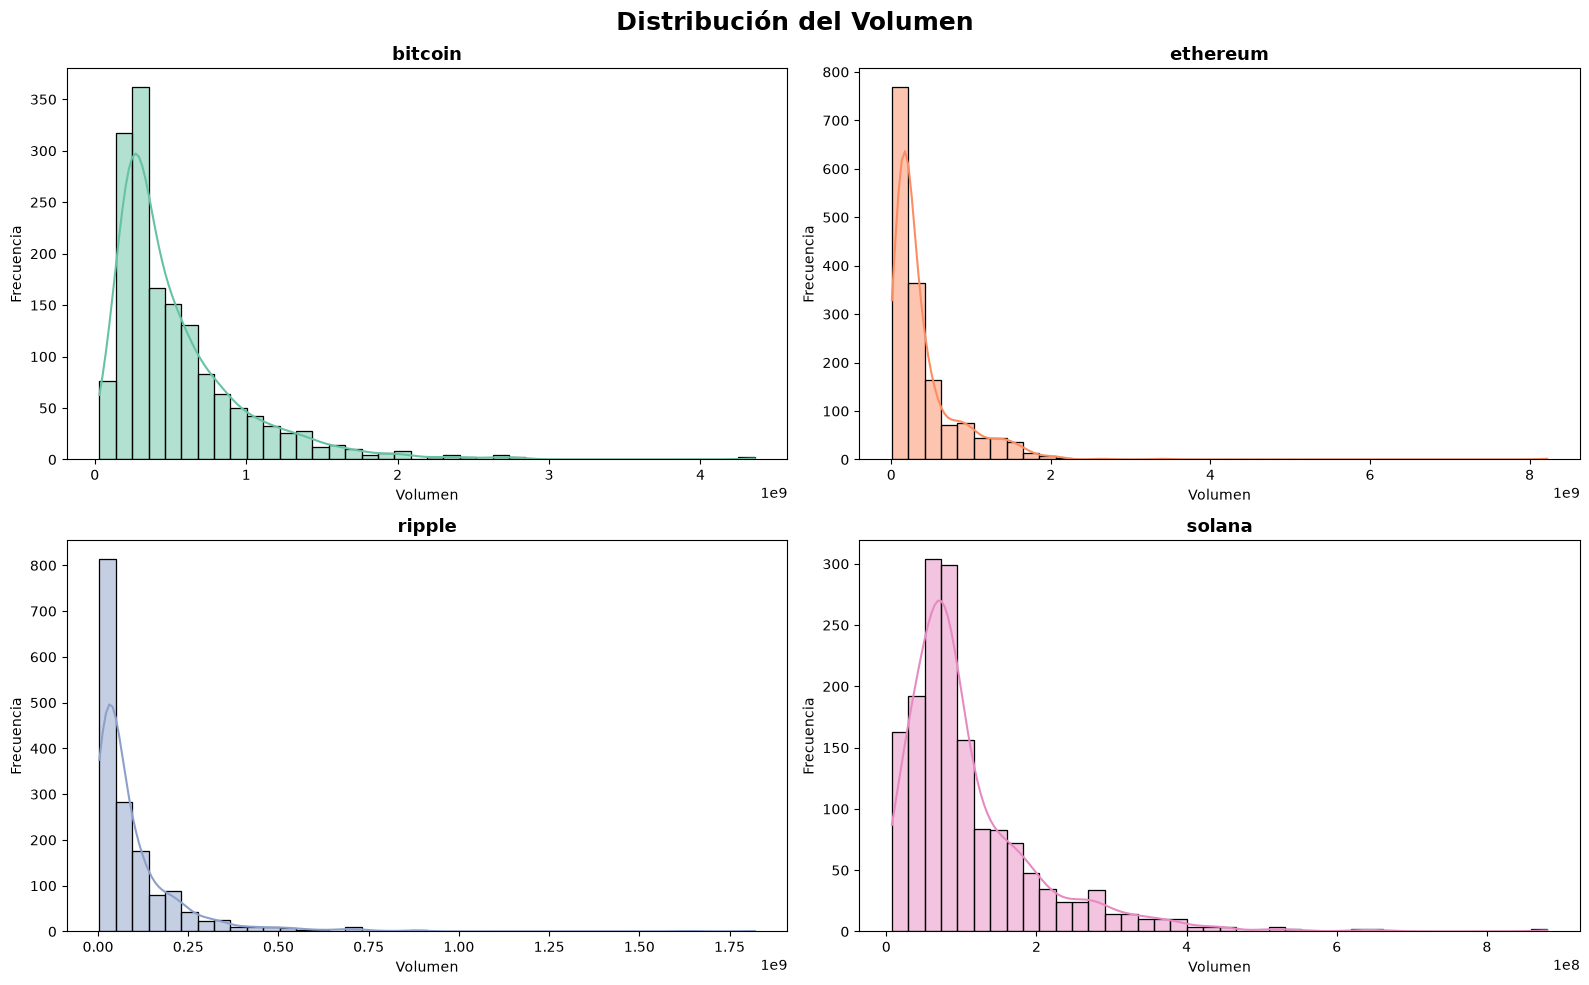

In [18]:
histograma_por_crypto(df,
                      "volume",
                      "Distribución del Volumen",
                      "Volumen",
                      bins=40)

Interpretación

El volumen negociado presenta una distribución altamente sesgada hacia la derecha. Se observan numerosos valores atípicos, propios de jornadas con una actividad extraordinaria de compraventa. Este comportamiento es habitual en los mercados financieros y refleja eventos de alta volatilidad o incrementos significativos en la demanda.

# Volumen

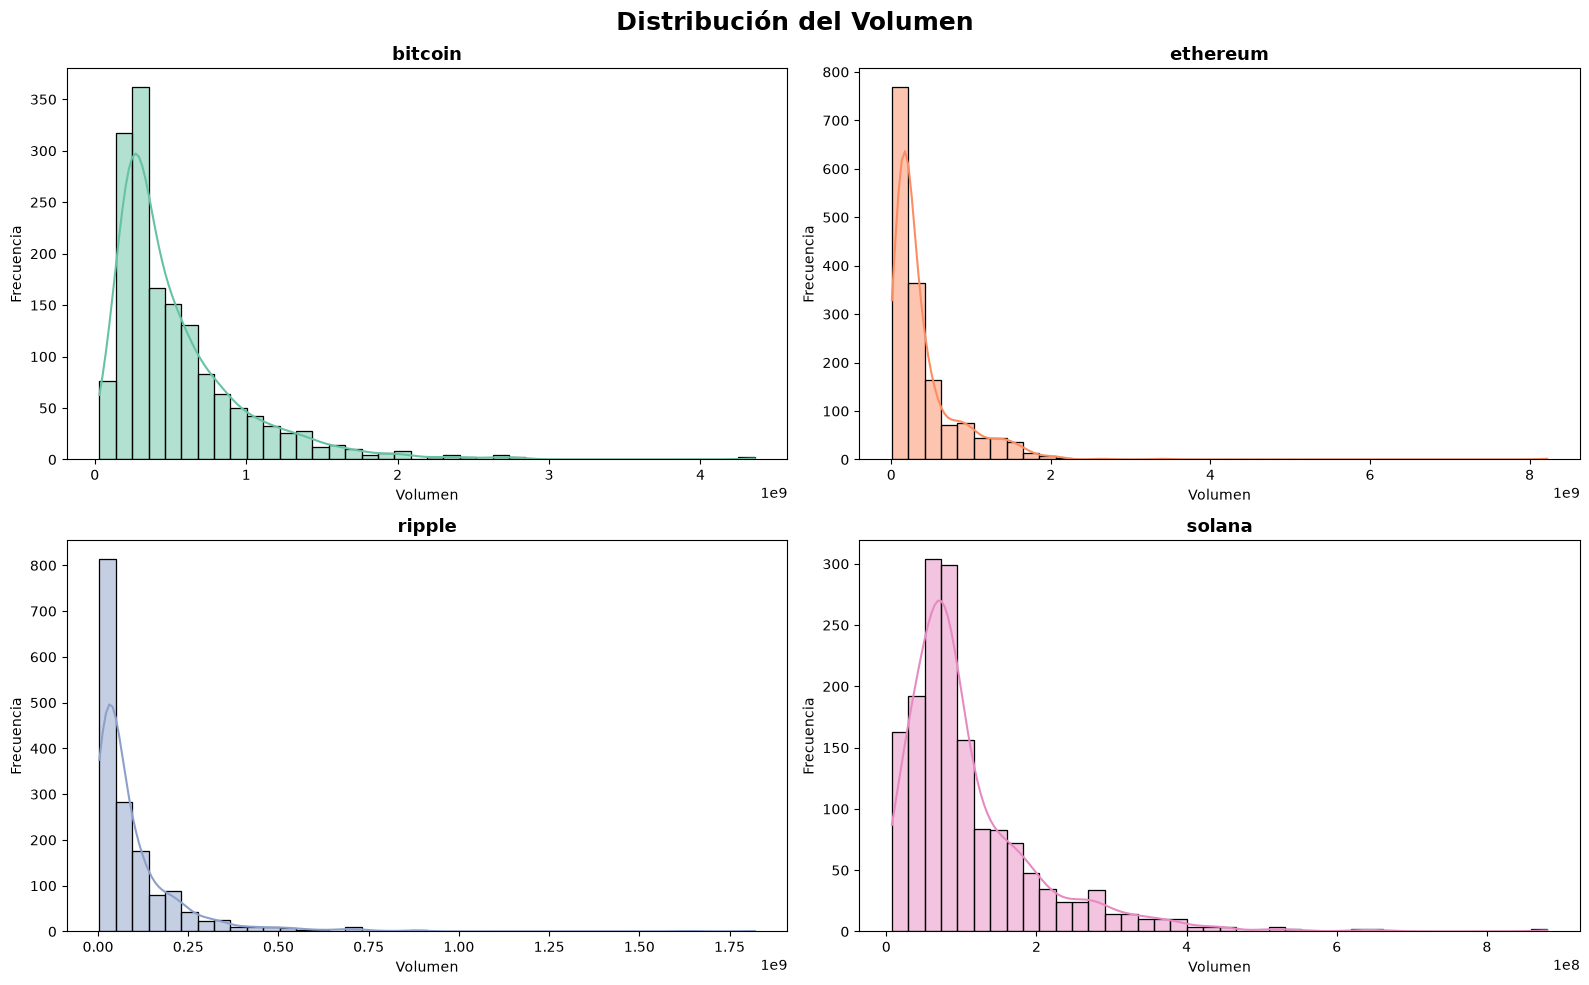

In [19]:
histograma_por_crypto(df,
                      "volume",
                      "Distribución del Volumen",
                      "Volumen",
                      bins=40)

Interpretación:

El volumen negociado presenta una elevada dispersión y numerosos valores extremos, reflejando jornadas de intensa actividad comercial.

# Retorno diario

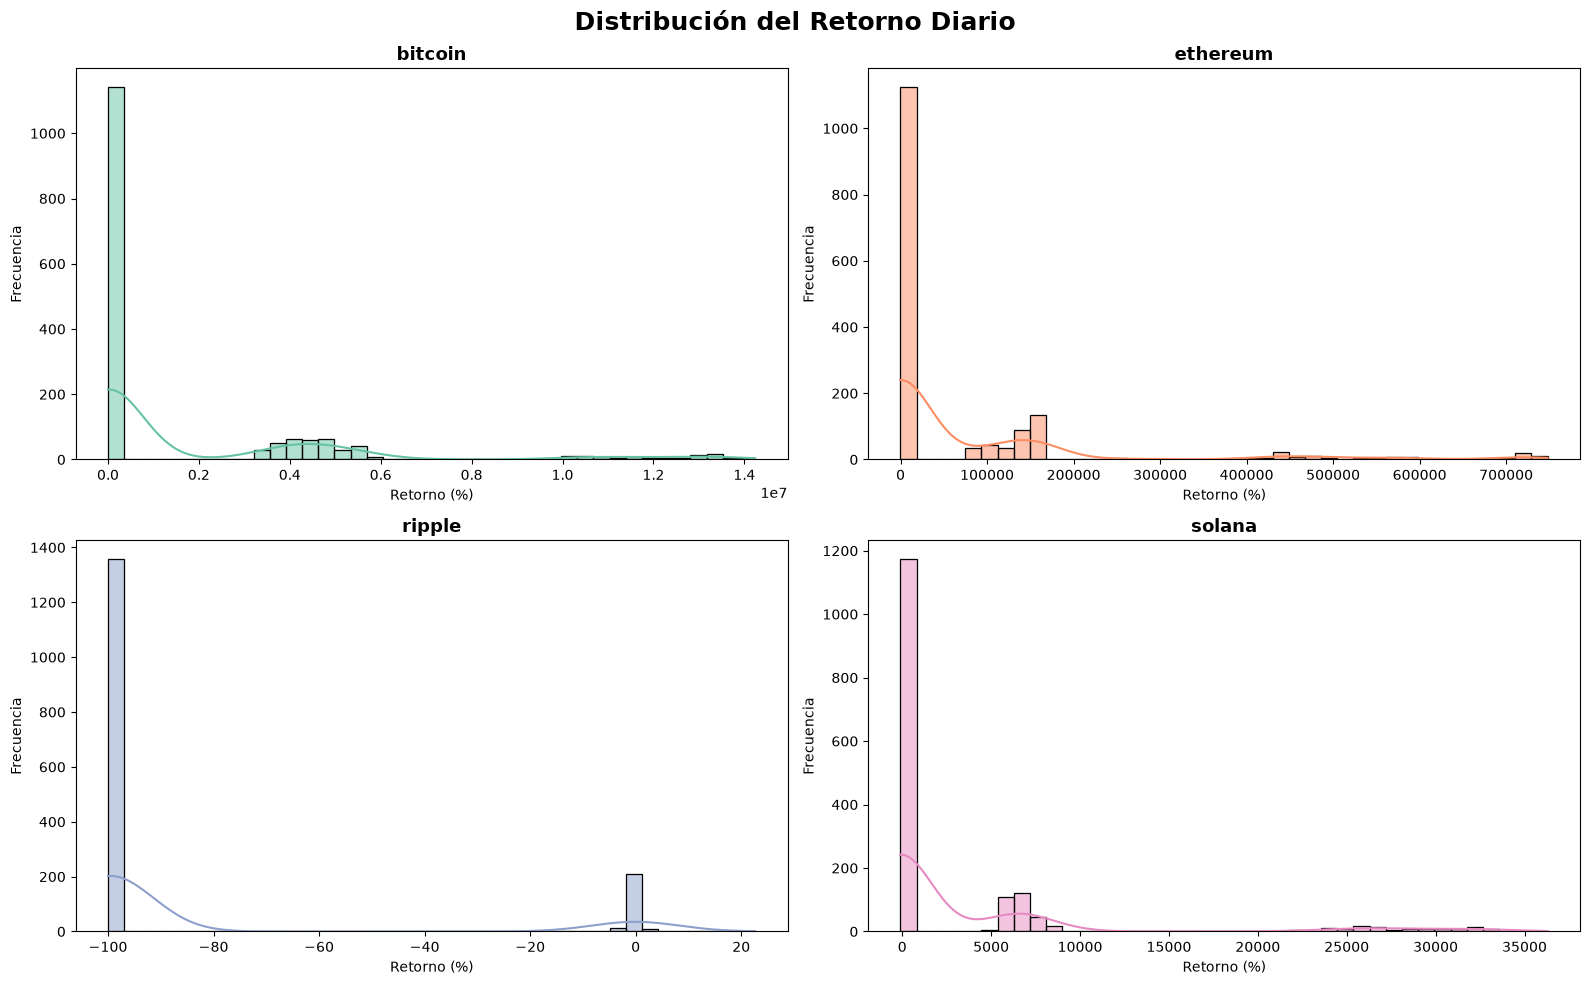

In [20]:
histograma_por_crypto(df,
                      "retorno_bitcoin",
                      "Distribución del Retorno Diario",
                      "Retorno (%)",
                      bins=40)

Interpretación:

La mayor parte de los retornos diarios se concentran alrededor del 0 %, indicando que las variaciones diarias suelen ser moderadas. Sin embargo, existen algunos retornos extremos positivos y negativos asociados a episodios de alta volatilidad.

# Función para series temporales

In [21]:
def serie_temporal(df,
                   variable,
                   titulo,
                   ylabel):

    fig, axes = plt.subplots(2,2,figsize=(18,10))

    criptos = df["crypto_id"].unique()

    colores = sns.color_palette("Set2", len(criptos))

    for ax, crypto, color in zip(axes.flatten(),
                                 criptos,
                                 colores):

        datos = df[df["crypto_id"] == crypto]

        sns.lineplot(
            data=datos,
            x="fecha",
            y=variable,
            color=color,
            linewidth=2,
            ax=ax
        )

        ax.set_title(crypto,
                     fontsize=13,
                     fontweight="bold")

        ax.set_xlabel("Fecha")
        ax.set_ylabel(ylabel)

        ax.grid(alpha=.3)

    plt.suptitle(titulo,
                 fontsize=18,
                 fontweight="bold")

    plt.tight_layout()

    plt.show()

# Serie temporal del precio

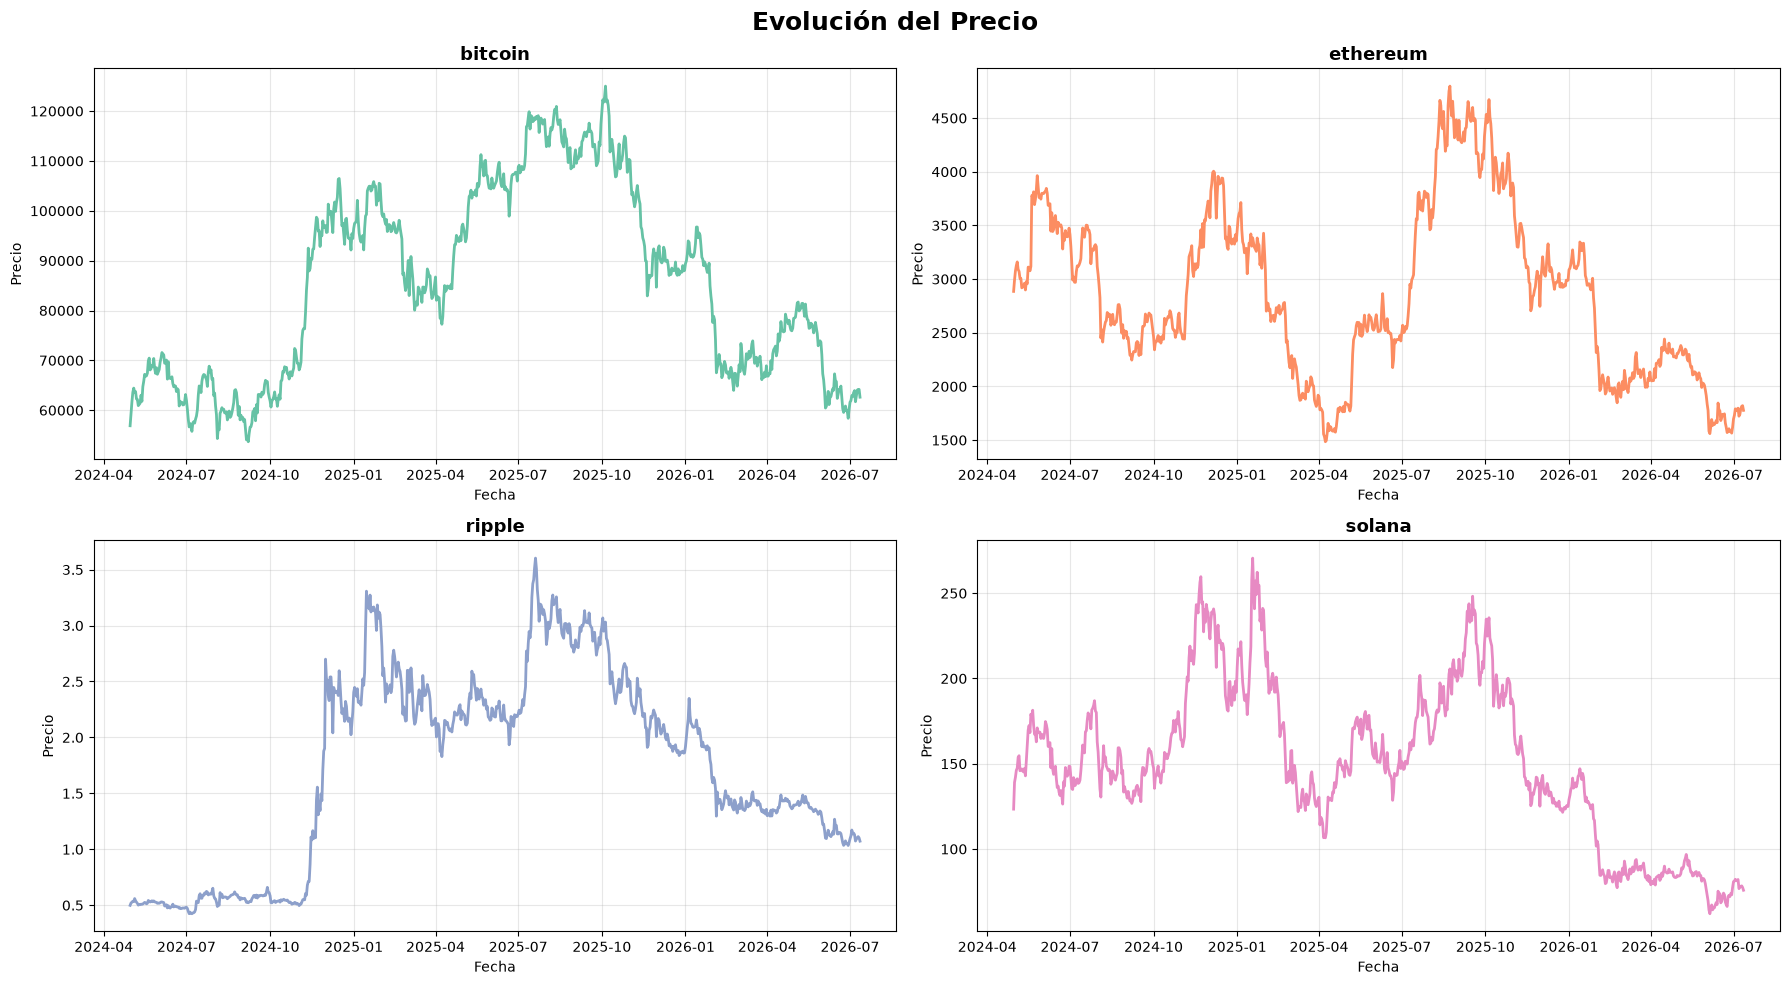

In [22]:
serie_temporal(df,
               "close",
               "Evolución del Precio",
               "Precio")

# Función para medias móviles

In [23]:
def media_movil(df,
                variable,
                media,
                titulo,
                ylabel):

    fig, axes = plt.subplots(2,2,figsize=(18,10))

    criptos = df["crypto_id"].unique()

    colores = sns.color_palette("Set2", len(criptos))

    for ax, crypto, color in zip(axes.flatten(),
                                 criptos,
                                 colores):

        datos = df[df["crypto_id"] == crypto]

        ax.plot(
            datos["fecha"],
            datos[variable],
            color=color,
            alpha=.35,
            label="Diario"
        )

        ax.plot(
            datos["fecha"],
            datos[media],
            color="black",
            linewidth=2.5,
            label="Media móvil"
        )

        ax.legend()

        ax.grid(alpha=.3)

        ax.set_title(crypto,
                     fontsize=13,
                     fontweight="bold")

        ax.set_xlabel("Fecha")
        ax.set_ylabel(ylabel)

    plt.suptitle(titulo,
                 fontsize=18,
                 fontweight="bold")

    plt.tight_layout()

    plt.show()

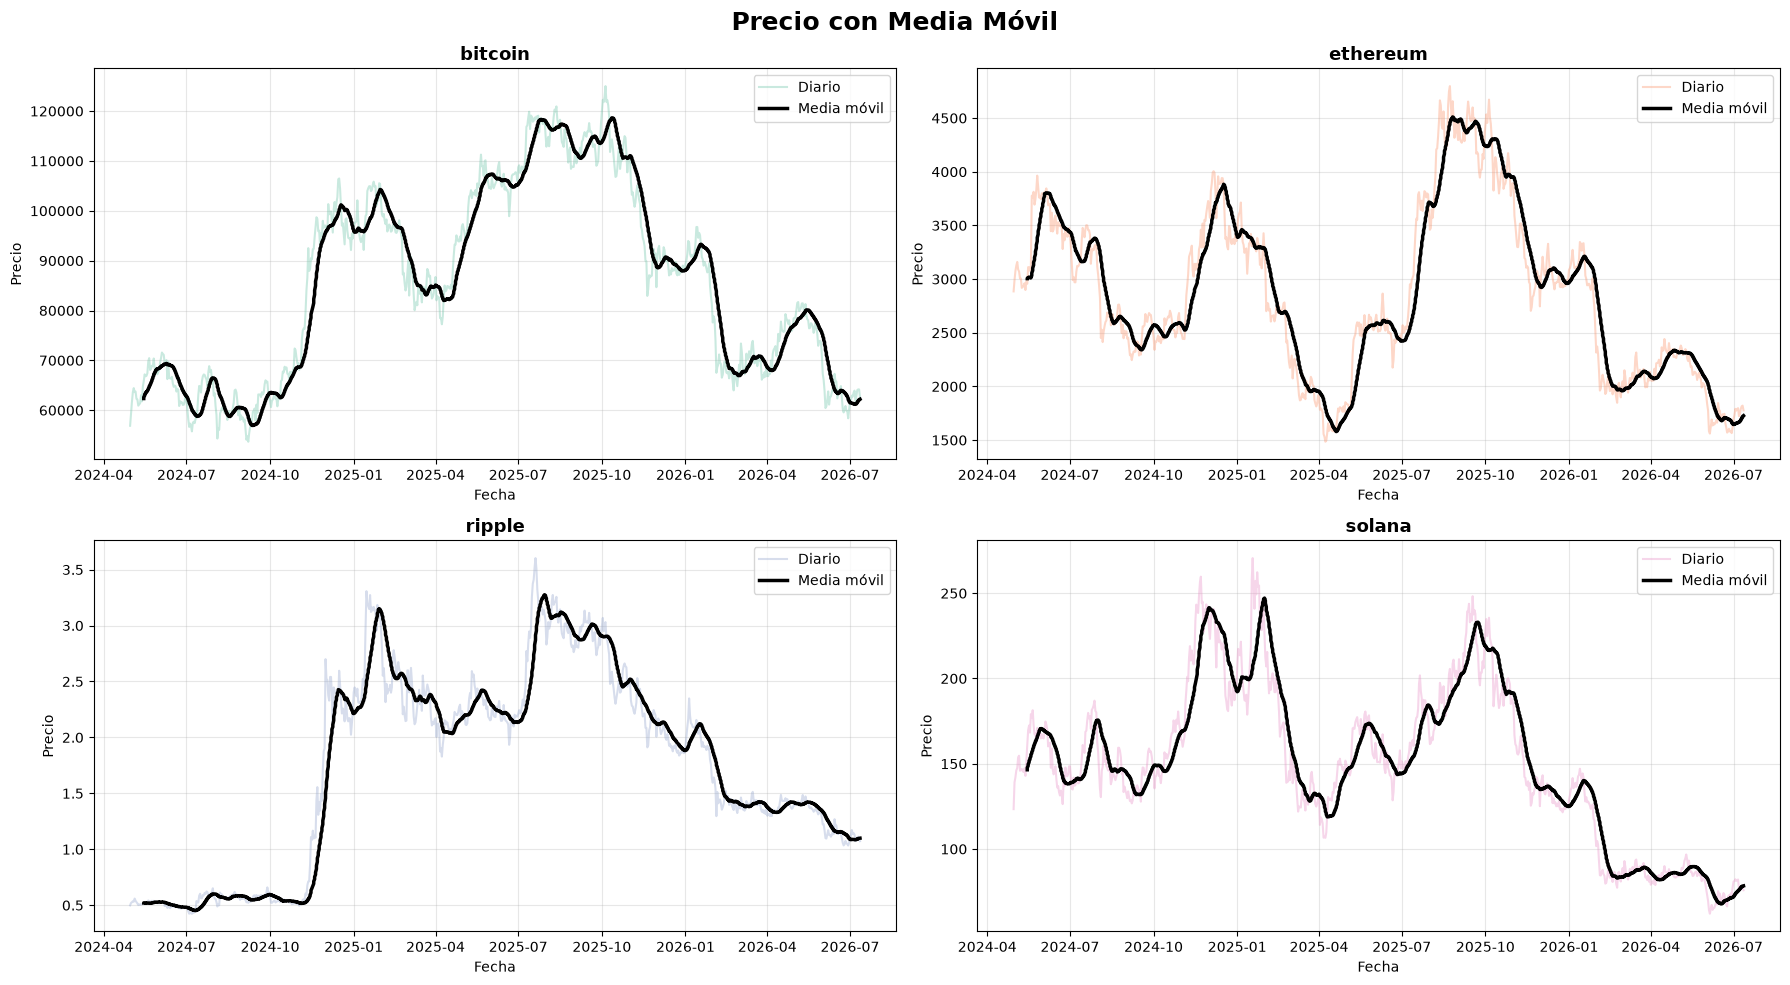

In [24]:
media_movil(df,
            "close",
            "media_movil_30",
            "Precio con Media Móvil",
            "Precio")

Interpretación

La media móvil de 30 días suaviza las fluctuaciones diarias del precio y permite identificar con mayor claridad la tendencia general del mercado. Se observa una evolución creciente durante gran parte del período analizado, aunque también aparecen fases de corrección y elevada volatilidad.

# Volumen suavizado

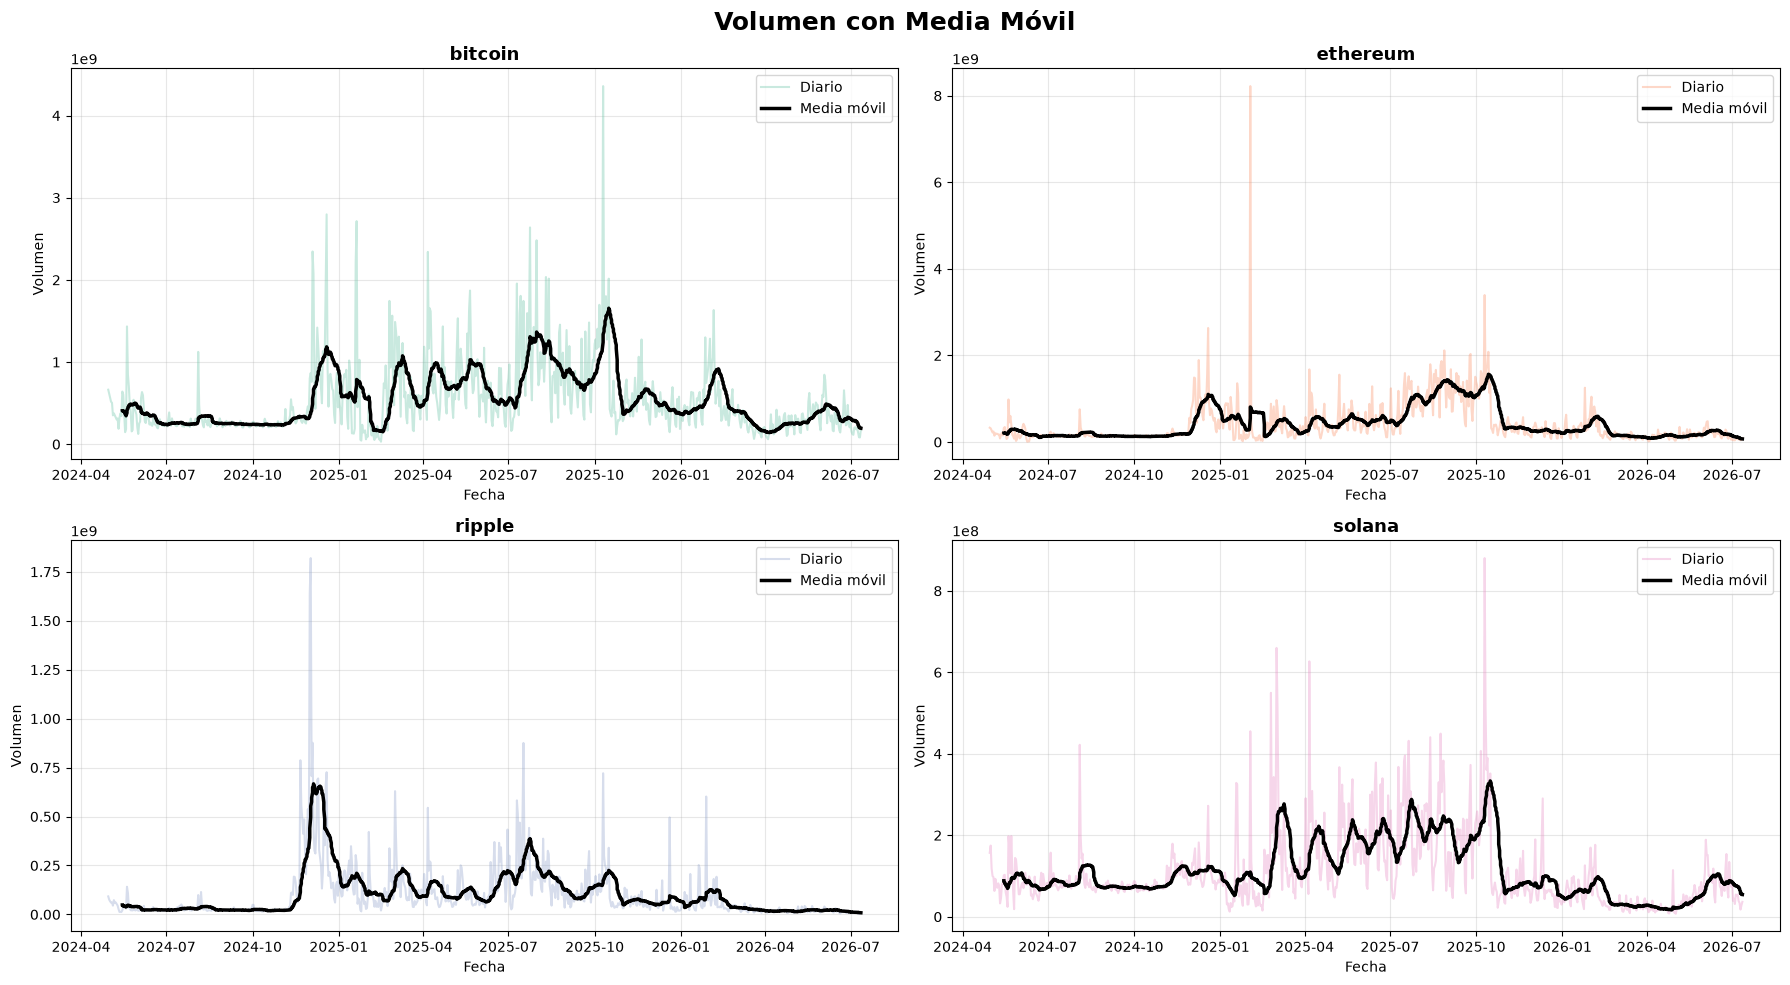

In [25]:
media_movil(df,
            "volume",
            "volumen_mm30",
            "Volumen con Media Móvil",
            "Volumen")

# Conclusión 


El análisis univariado permitió comprender el comportamiento individual de las variables que describen la evolución del precio de Bitcoin. Se observó una distribución asimétrica en los precios y en el volumen negociado, característica habitual de los mercados financieros. Los valores atípicos detectados corresponden a movimientos reales del mercado y reflejan episodios de elevada volatilidad. La incorporación de variables derivadas, como el retorno diario y la media móvil, aporta una mejor comprensión de la rentabilidad y de la tendencia del activo a lo largo del tiempo.